In [117]:
library(ggplot2)
library(tidyverse)
library(dplyr)
library(readr)
install.packages("pheatmap")
install.packages("scales")
install.packages("readxl")
library(readxl)
library(scales)
library(pheatmap)
install.packages("corrplot")
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# **`- Carregamento dos dados.`**

In [118]:
HREmployeeDF <- read.csv2("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [119]:
head(HREmployeeDF)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0
4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,⋯,3,80,0,8,3,3,8,7,3,0
5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,⋯,4,80,1,6,3,3,2,2,2,2
6,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,⋯,3,80,0,8,2,2,7,7,3,6


In [120]:
dim(HREmployeeDF)

[1] 1470   35

In [121]:
summary(HREmployeeDF)

      Age            Attrition      BusinessTravel   DailyRate     
 Min.   :18.00   Length   :1470   Length   :1470   Min.   : 102.0  
 1st Qu.:30.00   N.unique :   2   N.unique :   3   1st Qu.: 465.0  
 Median :36.00   N.blank  :   0   N.blank  :   0   Median : 802.0  
 Mean   :36.92   Min.nchar:   2   Min.nchar:  10   Mean   : 802.5  
 3rd Qu.:43.00   Max.nchar:   3   Max.nchar:  17   3rd Qu.:1157.0  
 Max.   :60.00                                     Max.   :1499.0  
     Department   DistanceFromHome   Education       EducationField
 Length   :1470   Min.   : 1.000   Min.   :1.000   Length   :1470  
 N.unique :   3   1st Qu.: 2.000   1st Qu.:2.000   N.unique :   6  
 N.blank  :   0   Median : 7.000   Median :3.000   N.blank  :   0  
 Min.nchar:   5   Mean   : 9.193   Mean   :2.913   Min.nchar:   5  
 Max.nchar:  22   3rd Qu.:14.000   3rd Qu.:4.000   Max.nchar:  16  
                  Max.   :29.000   Max.   :5.000                   
 EmployeeCount EmployeeNumber   EnvironmentSatis

# **-Distribuição dos Trabalhadores por Departamento. (usando o boxplot)**




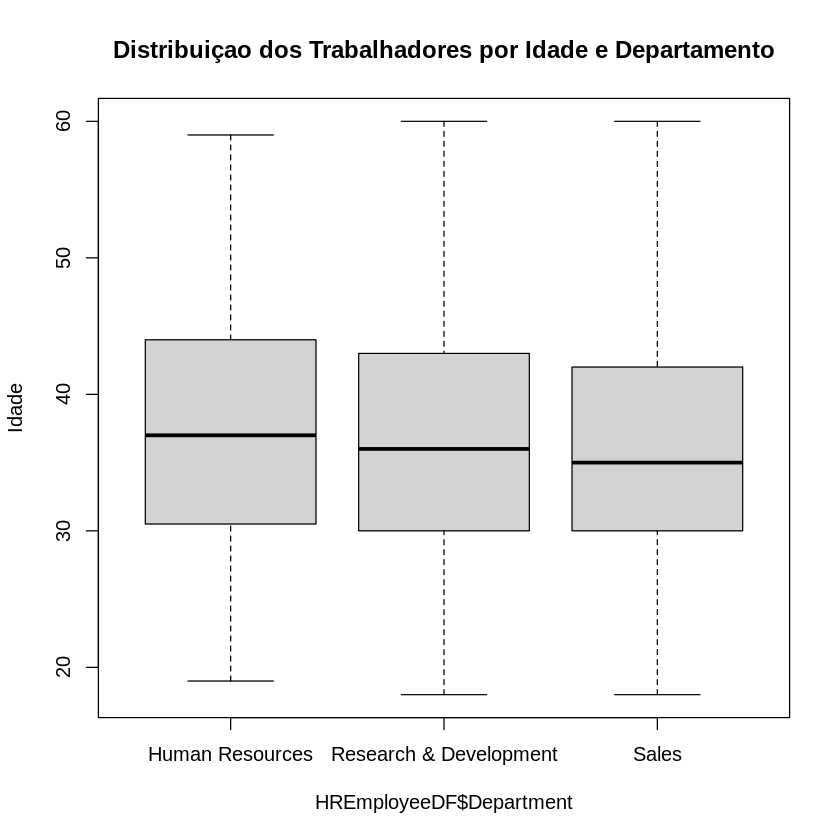

In [122]:
boxplot(HREmployeeDF$Age ~ HREmployeeDF$Department, main ="Distribuiçao dos Trabalhadores por Idade e Departamento", ylab = "Idade")

In [123]:
HREmployeeDF %>%
  group_by(Department,Gender) %>% summarise(EmployeeNumber =n(),.groups = "drop_last")

Department,Gender,EmployeeNumber
<chr>,<chr>,<int>
Human Resources,Female,20
Human Resources,Male,43
Research & Development,Female,379
Research & Development,Male,582
Sales,Female,189
Sales,Male,257


# **- Idade media dos trabalhadores.**

In [124]:
HREmployeeDF %>%
  group_by(Gender) %>%
  summarise(Idade_Media = mean(Age))

Gender,Idade_Media
<chr>,<dbl>
Female,37.32993
Male,36.65306


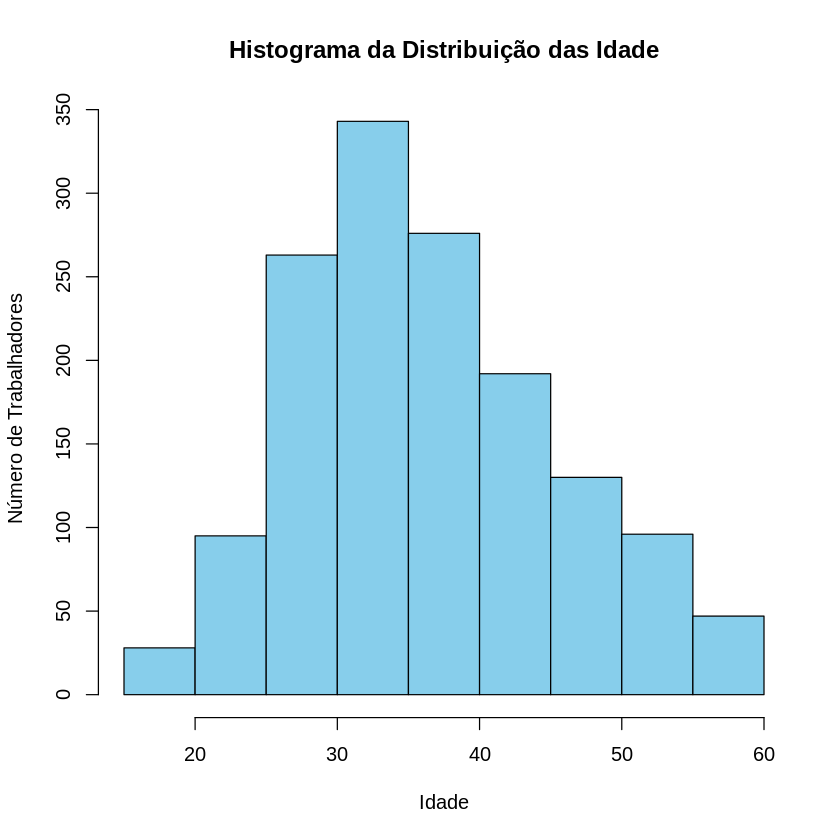

In [125]:
hist(HREmployeeDF$Age, main = "Histograma da Distribuição das Idade", xlab = "Idade", ylab = "Número de Trabalhadores", col = "skyblue")

# **- Idade mediana dos trabalhadores.**

In [126]:
HREmployeeDF %>%
  group_by(Gender) %>%
  summarise(Idade_Mediana= median(Age))

Gender,Idade_Mediana
<chr>,<dbl>
Female,36
Male,35


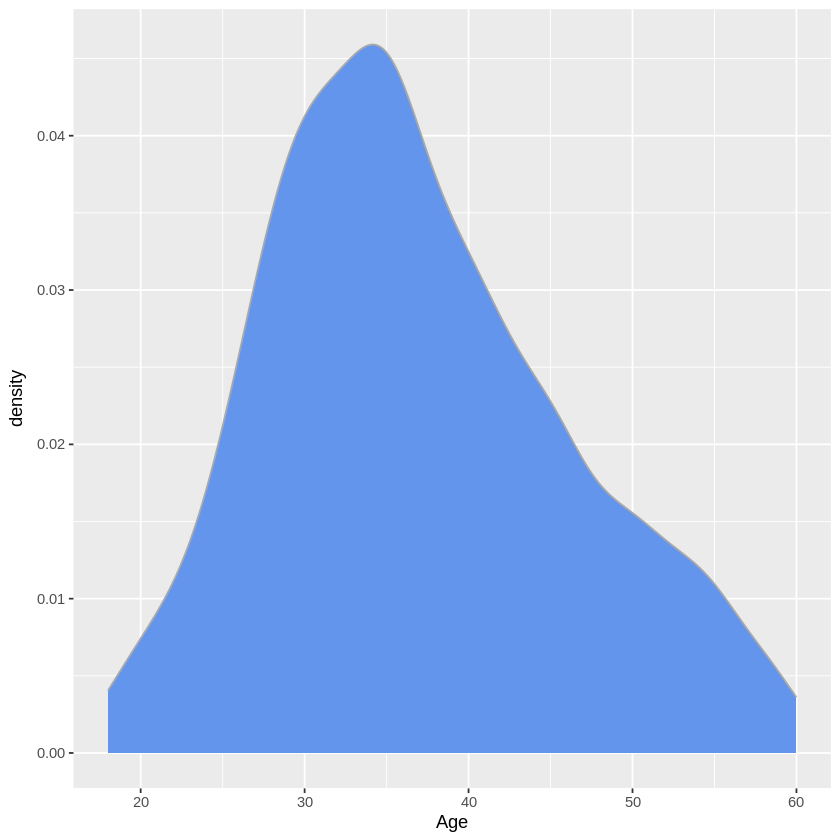

In [127]:
HREmployeeDF %>%
  filter( Age >=18 ) %>%
  ggplot( aes(x=Age)) +
    geom_density(fill="#6495ed", color="#a9a9a9", alpha=1)

# **- Distribuiçao dos trabalhadores por genero em percentagem.**

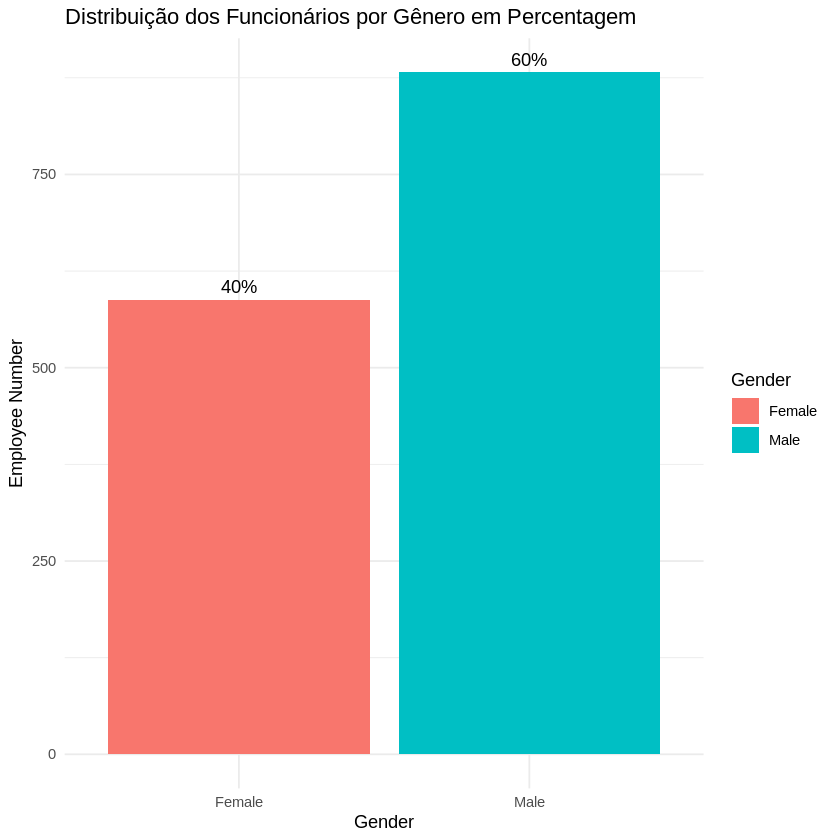

In [128]:
HREmployeeDF %>%
  ggplot(aes(x = Gender, fill = Gender)) +
  geom_bar() +
  geom_text(
    stat = "count",
    aes(label = percent(after_stat(count / sum(count)))),
    vjust = -0.5) +
  labs( title = "Distribuição dos Funcionários por Gênero em Percentagem",
    x = "Gender",
    y = "Employee Number") + theme_minimal()

# **- Distribuição dos trabalhadores por departamento e genero.**

In [129]:
HREmployeeDF %>%
  group_by(Department,Gender) %>% summarise(EmployeeNumber =n(),.groups = "drop_last") %>%
 mutate(Valor_Percentagem =(EmployeeNumber/sum(EmployeeNumber))*100)


Department,Gender,EmployeeNumber,Valor_Percentagem
<chr>,<chr>,<int>,<dbl>
Human Resources,Female,20,31.74603
Human Resources,Male,43,68.25397
Research & Development,Female,379,39.43809
Research & Development,Male,582,60.56191
Sales,Female,189,42.37668
Sales,Male,257,57.62332


# **- Trabalhadores em entrada para idade de reforma.**

In [130]:
HREmployeeDF[HREmployeeDF$Age == 60, c("Age", "Department","Gender")]

,Age,Department,Gender
,<int>,<chr>,<chr>
412,60,Research & Development,Female
428,60,Sales,Female
537,60,Sales,Male
880,60,Sales,Male
1210,60,Research & Development,Male


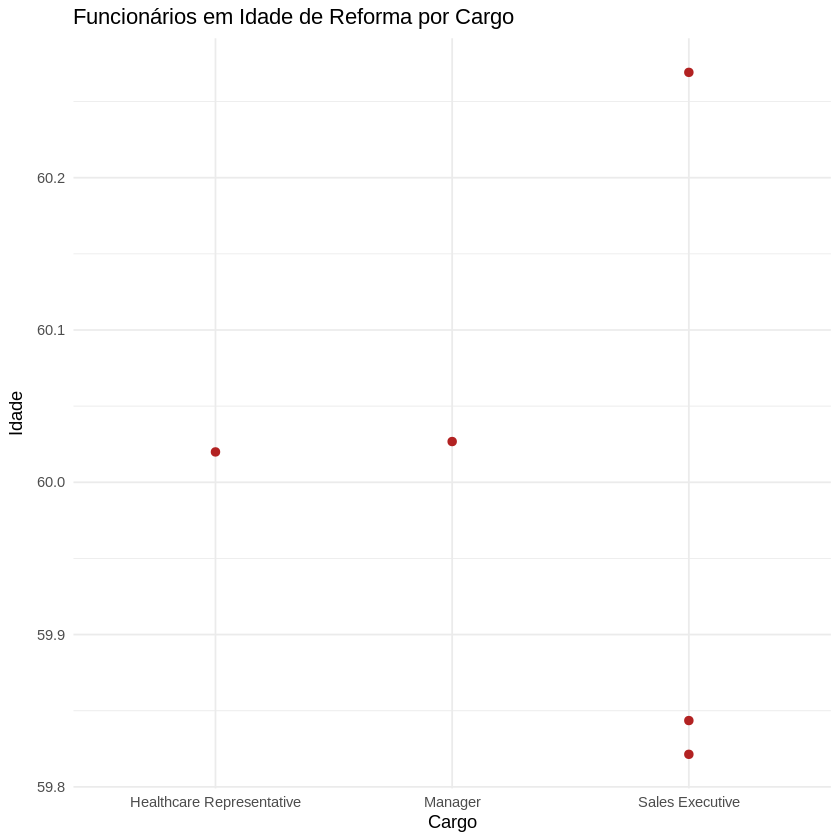

In [131]:
Age60 <- subset.data.frame(HREmployeeDF, Age == 60)

ggplot(Age60, aes(x = JobRole, y = Age)) +
  geom_area(fill = "blue") +
  geom_jitter(colour = "firebrick",
              size = 2,
              width =0.0) +
  labs(
    title = "Funcionários em Idade de Reforma por Cargo",
    x = "Cargo",
    y = "Idade"
  ) +
  theme_minimal()


# **- Estudo do indice da felecidade dos trabalhadores.**

In [132]:
cor(HREmployeeDF$WorkLifeBalance,HREmployeeDF$JobSatisfaction, method = "pearson")

[1] -0.01945871

In [133]:
cor(HREmployeeDF$WorkLifeBalance,HREmployeeDF$RelationshipSatisfaction, method = "pearson")

[1] 0.01960441

In [134]:
cor(HREmployeeDF$WorkLifeBalance,HREmployeeDF$EnvironmentSatisfaction, method = "pearson")

[1] 0.0276273

# **- Analise dos salarios com base o nivel dos trabalhadores.**

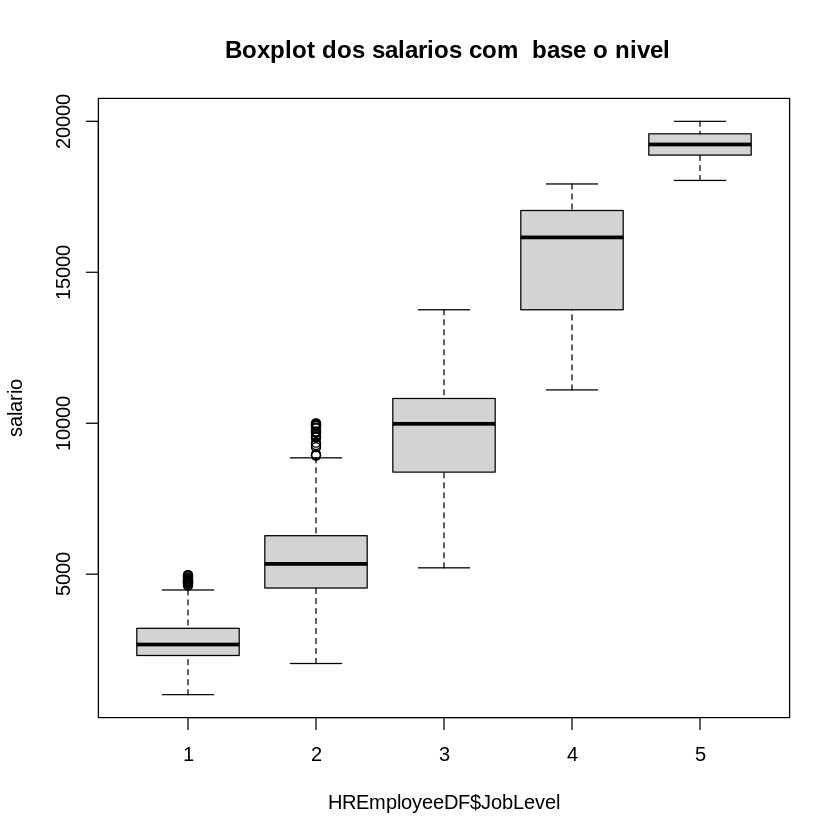

In [135]:
boxplot(HREmployeeDF$MonthlyIncome ~ HREmployeeDF$JobLevel, main =" Boxplot dos salarios com  base o nivel", ylab = "salario")

# **- Com um grafico de dispersão.**

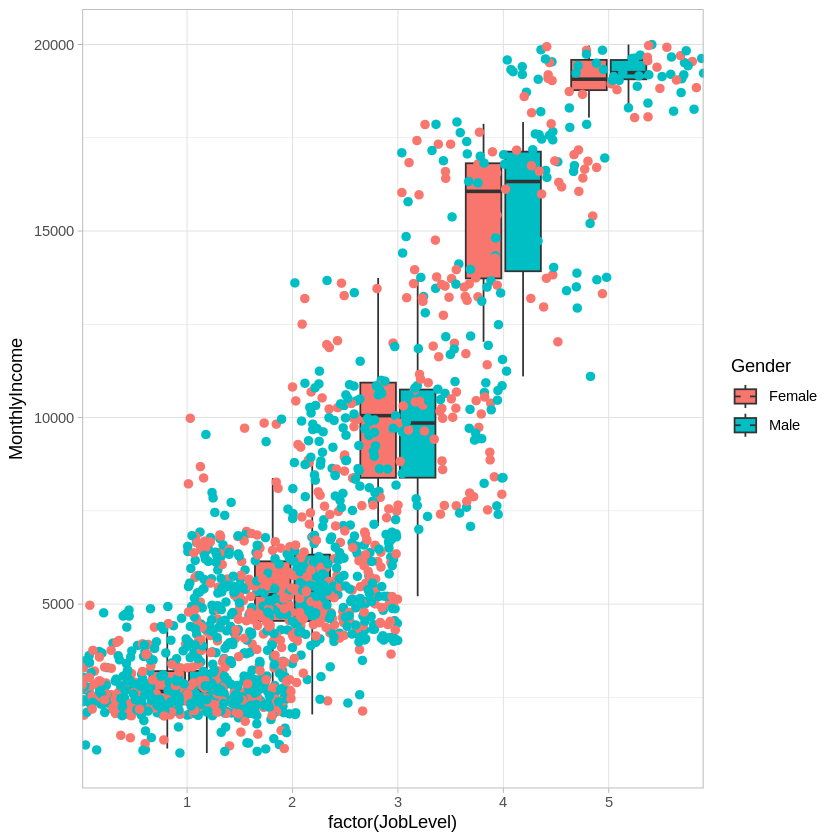

In [136]:
HREmployeeDF %>%
  ggplot(aes(x = factor(JobLevel),
             y = MonthlyIncome,
             fill = Gender)) +
  geom_boxplot(alpha = 3, outlier.shape = NA) +
  geom_jitter(aes(color = Gender),
              width = 1,
              alpha = 5,
              size = 2) +
  theme_light()

# **- Analise do salario medio com base o nivel.**

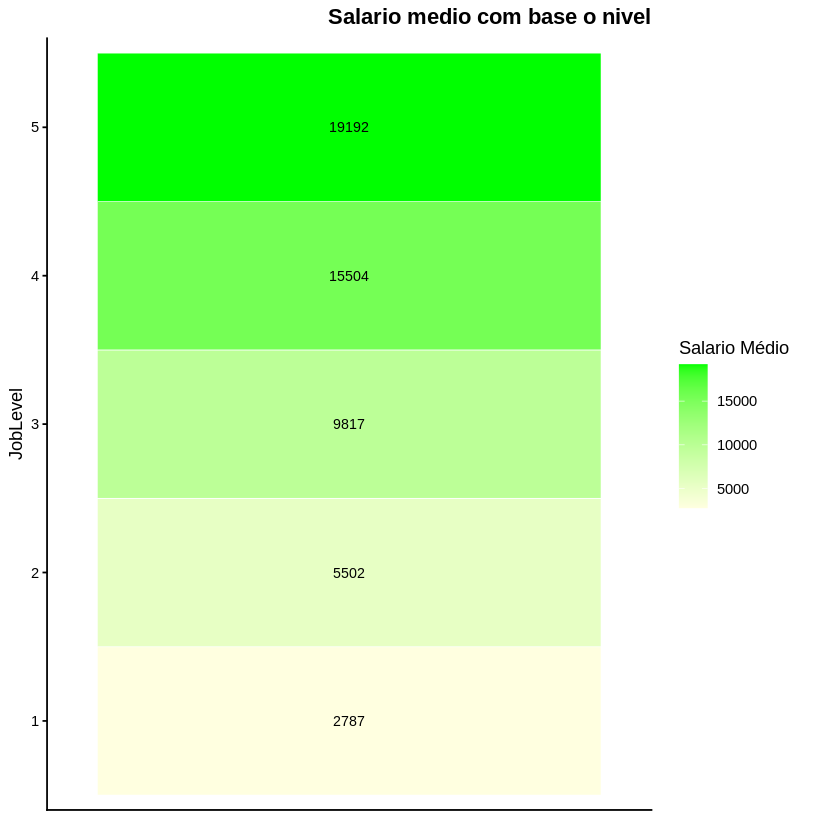

In [137]:
HREmployeeDF %>%
  group_by(JobLevel) %>%
  summarise(MeanIncome = mean(MonthlyIncome, na.rm = TRUE),
            .groups = "drop") %>%
  ggplot(aes(x = "Monthly Income", y = reorder(JobLevel, MeanIncome), fill = MeanIncome)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(MeanIncome, 0)), color = "black", size = 3) +
  scale_fill_gradient(low = "lightyellow", high = "green") +
  labs(
    title = "Salario medio com base o nivel",
    x = "",
    y = "JobLevel",
    fill = "Salario Médio"
  ) +
  theme_classic() +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    plot.title = element_text(face = "bold", hjust = 1)
  )

# **- Analise da mediana salarial com base o nivel e genero.**

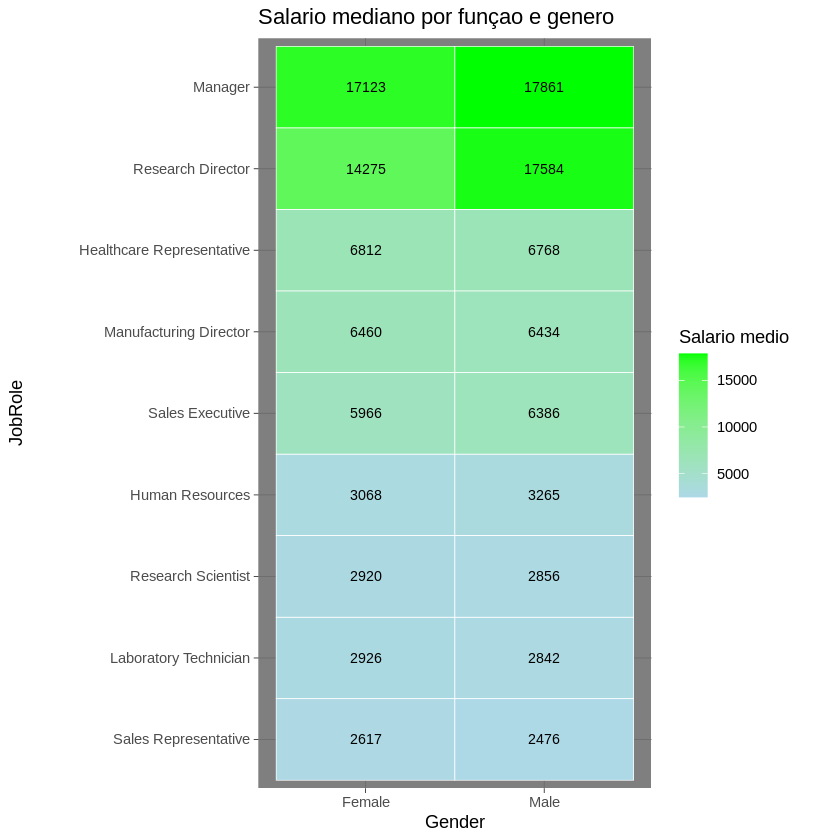

In [138]:
HREmployeeDF %>%
  group_by(JobRole, Gender) %>%
  summarise(MedianIncome = median(MonthlyIncome, na.rm = TRUE),
            .groups = "drop") %>%
  ggplot(aes(x = Gender,
             y = reorder(JobRole, MedianIncome),
             fill = MedianIncome)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(MedianIncome, 0)), size = 3) +
  scale_fill_gradient(low = "lightblue", high = "green") +
  labs(
    title = "Salario mediano por funçao e genero",
    x = "Gender",
    y = "JobRole",
    fill = "Salario medio"
  ) +
  theme_dark()

# **-Estudo do Survey.**

In [139]:
SurveyPPTableDF <- read_excel("/content/SurveyPingPongTable.xlsx")

In [140]:

head.matrix(SurveyPPTableDF)

employee_number,environment_satisfaction,job_involvement,job_satisfaction,relationship_satisfaction,work_life_balance
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
699,2,4,2,3,3
643,2,4,2,3,4
615,2,4,1,3,3
534,2,4,1,3,3
530,2,4,1,3,3
496,2,4,2,3,3


In [141]:
summary(SurveyPPTableDF)

 employee_number environment_satisfaction job_involvement job_satisfaction
 Min.   :   2    Min.   :1.000            Min.   :3.000   Min.   :1.000   
 1st Qu.: 483    1st Qu.:2.000            1st Qu.:3.000   1st Qu.:2.000   
 Median :1022    Median :2.000            Median :3.000   Median :3.000   
 Mean   :1028    Mean   :1.828            Mean   :3.397   Mean   :2.448   
 3rd Qu.:1574    3rd Qu.:2.000            3rd Qu.:4.000   3rd Qu.:3.000   
 Max.   :2068    Max.   :2.000            Max.   :4.000   Max.   :3.000   
 relationship_satisfaction work_life_balance
 Min.   :1.000             Min.   :1.000    
 1st Qu.:2.000             1st Qu.:2.000    
 Median :3.000             Median :3.000    
 Mean   :2.781             Mean   :2.734    
 3rd Qu.:3.000             3rd Qu.:4.000    
 Max.   :4.000             Max.   :4.000    

In [142]:
SurveyPPTable.Cor = cor(SurveyPPTableDF)

In [143]:
SurveyPPTable.Cor =cor(SurveyPPTableDF, method = "pearson")

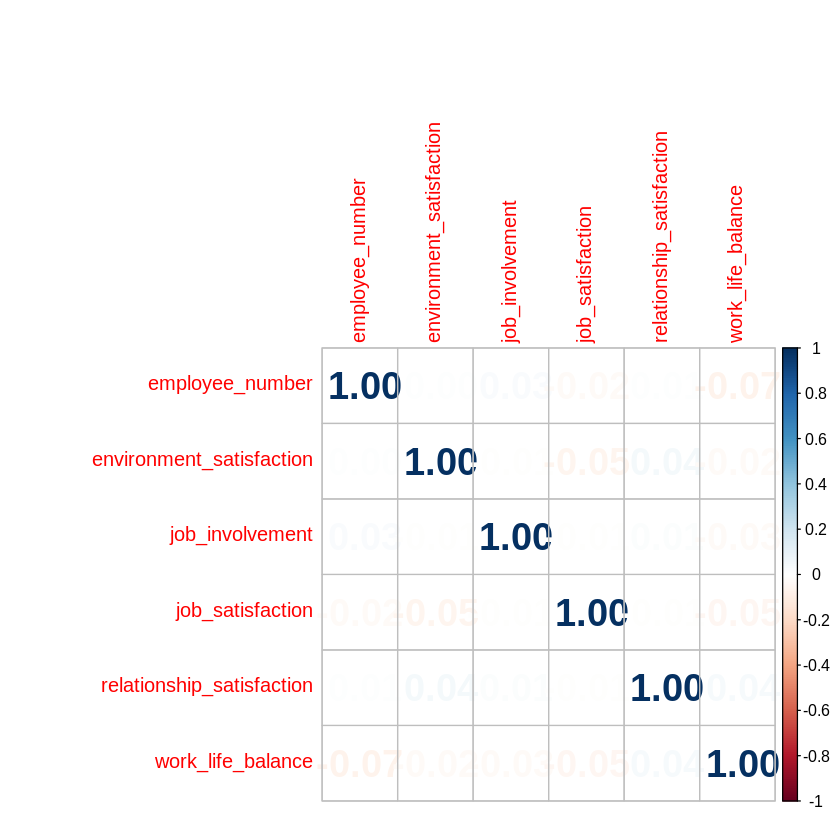

In [144]:
corrplot(SurveyPPTable.Cor, method = "number", number.cex = 1.9 )